In [1]:
!pip install tensorflow numpy pandas scikit-learn matplotlib

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
print(tf.__version__)

2.18.0


In [4]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_features = 10000
maxlen = 500
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_train = pad_sequences(x_train, maxlen=maxlen)
X_test = pad_sequences(x_test, maxlen=maxlen)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
model = Sequential([
Embedding(max_features, 32, input_length=maxlen),
SimpleRNN(32),
Dense(1,activation='sigmoid')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 163ms/step - accuracy: 0.5676 - loss: 0.6798 - val_accuracy: 0.7772 - val_loss: 0.5145
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - accuracy: 0.8103 - loss: 0.4472 - val_accuracy: 0.8346 - val_loss: 0.3883
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.8838 - loss: 0.3007 - val_accuracy: 0.8486 - val_loss: 0.3763
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 173ms/step - accuracy: 0.9280 - loss: 0.2027 - val_accuracy: 0.8396 - val_loss: 0.3866
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 158ms/step - accuracy: 0.9685 - loss: 0.1080 - val_accuracy: 0.8396 - val_loss: 0.4370
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.9848 - loss: 0.0594 - val_accuracy: 0.8184 - val_loss: 0.4932
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.9843 - loss: 0.0533 - val_accuracy: 0.8386 - val_loss: 0.5095
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 156ms/step - accuracy: 0.9958 - loss: 0

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8352 - loss: 0.6146
Test accuracy: 0.8364


In [10]:
from tensorflow.keras.layers import Dropout
model = Sequential([
Embedding(max_features, 32, input_length=maxlen),
SimpleRNN(32,return_sequences=False),
Dropout(0.5),
Dense(1,activation='sigmoid')])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [11]:
from tensorflow.keras.layers import LSTM
model = Sequential([
Embedding(max_features, 32, input_length=maxlen),
LSTM(32),
Dense(1,activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.layers import GRU
model = Sequential([
Embedding(max_features, 32, input_length=maxlen),
GRU(32),
Dense(1,activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 417ms/step - accuracy: 0.6166 - loss: 0.6308 - val_accuracy: 0.8412 - val_loss: 0.3674
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 403ms/step - accuracy: 0.8855 - loss: 0.2764 - val_accuracy: 0.8746 - val_loss: 0.3112
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 411ms/step - accuracy: 0.9314 - loss: 0.1897 - val_accuracy: 0.8692 - val_loss: 0.3266
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 413ms/step - accuracy: 0.9306 - loss: 0.1875 - val_accuracy: 0.8746 - val_loss: 0.3415
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 412ms/step - accuracy: 0.9548 - loss: 0.1333 - val_accuracy: 0.8726 - val_loss: 0.3826


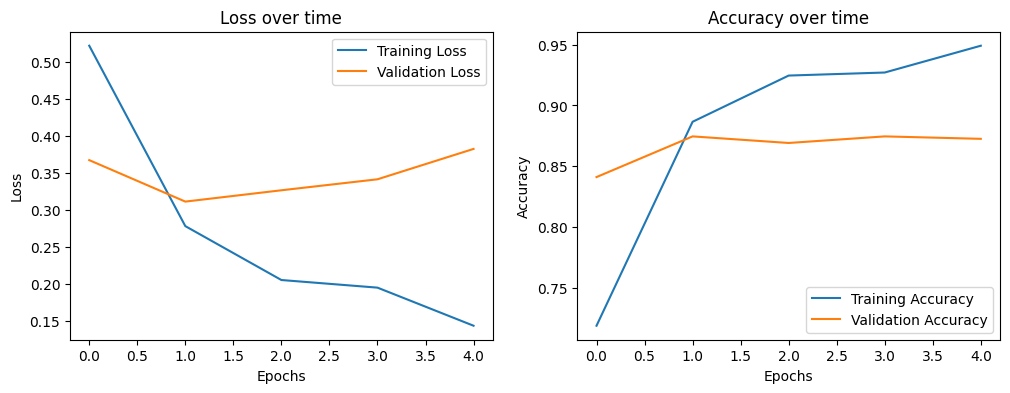

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('Training_metrics.png')

In [15]:
word_index = imdb.get_word_index()
def encode_review(text):
  tokens = text.lower().split()
  tokens = [word_index.get(word,0) for word in tokens]
  tokens = pad_sequences([tokens],maxlen=maxlen)
  return tokens

  new_review = 'This movie was amazing and truely captivating'
  encoded_review = encode_review(new_review)
  prediction = model.predict(encoded_review)[0][0]
  print(f"Sentiment: {'Positive' if prediction > 0.5 else 'Negative'}(Confidence:{prediction:.4f})" )

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
from tensorflow.keras.layers import Bidirectional
model = Sequential([
Embedding(max_features, 32, input_length=maxlen),
Bidirectional(LSTM(32)),
Dense(1,activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
model = Sequential([
   Embedding(max_features, 32, input_length=maxlen),
   LSTM(64, return_sequences=True),
   LSTM(32),
   Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [18]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
model.save('rnn_sentimental_model.h5')

from tensorflow.keras.models import load_model
model = load_model('rnn_sentimental_model.h5')

In [21]:
from tensorflow.keras.optimizers import Adam

# Instantiate the Adam optimizer with the desired argument
adam_optimizer = Adam(clipnorm=1.0)

# Compile the model using the instantiated optimizer
model.compile(optimizer=adam_optimizer, loss='binary_crossentropy', metrics=['accuracy'])